# OULAD Student Outcome Prediction: Modeling

This notebook trains and evaluates **Random Forest** (RAPIDS cuML) and **XGBoost** and **LightBGM** models.

In [1]:
# 1. Cài đặt các thư viện cơ bản
!pip install --upgrade -q numpy pandas matplotlib seaborn scikit-learn xgboost optuna jupyter

# 2. Cài đặt RAPIDS cho GPU (cuDF và cuML)
!pip install -q --extra-index-url https://pypi.nvidia.com cudf-cu12 cuml-cu12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 84.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 103.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 104.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 106.5 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.8 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
ydata-

In [2]:
# Check GPU availability
import subprocess
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print("✓ NVIDIA GPU Available:")
    print(result.stdout)
except FileNotFoundError:
    print("⚠ nvidia-smi not found. Ensure NVIDIA drivers are installed.")

✓ NVIDIA GPU Available:
Thu Apr 16 13:30:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------

In [3]:
# 1. Thư viện hệ thống cơ bản (Standard Libraries)
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

# 2. Tiện ích & Xử lý dữ liệu cơ bản (CPU)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning & Đánh giá (CPU / Framework chung)
import optuna
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 4. Thư viện tăng tốc GPU (RAPIDS & NVIDIA)
import pynvml
import cudf
import cuml
from cuml.model_selection import train_test_split as cuml_split
from cuml.ensemble import RandomForestClassifier as CuRFClassifier

## 1. Data Loading (GPU Memory)

Data is loaded directly to GPU VRAM for faster processing.
- **Train set**: 26,063 rows × 116 columns
- **Test set**: 6,530 rows × 116 columns

In [4]:
data_path = "/kaggle/input/datasets/thinhuit/dataset-1604/data"
start_time = time.time()


df_train = cudf.read_csv(os.path.join(data_path, 'df_train.csv'))
df_test = cudf.read_csv(os.path.join(data_path, 'df_test.csv'))
df_train_scaled = cudf.read_csv(os.path.join(data_path, 'df_train_scaled.csv'))
df_test_scaled = cudf.read_csv(os.path.join(data_path, 'df_test_scaled.csv'))
device_loc = 'GPU (VRAM)'
   
    
with open(os.path.join(data_path, 'feature_cols.json'), 'r') as f:
    feature_cols = json.load(f)

elapsed = time.time() - start_time
print(f"\n✓ Data loaded successfully to {device_loc}")
print(f"  Loading time: {elapsed:.2f}s")
print(f"  Train shape: {df_train.shape}")
print(f"  Test shape: {df_test.shape}")
print(f"  Features: {len(feature_cols)}")


✓ Data loaded successfully to GPU (VRAM)
  Loading time: 1.39s
  Train shape: (26063, 116)
  Test shape: (6530, 116)
  Features: 104


## 2. Feature Preparation 

104 features are selected and prepared:
- **VLE Temporal**: 24 features
- **Assessment**: 13 features  
- **Withdrawal Signals**: 15 features
- **Distinction Signals**: 20 features
- **Demographics**: 21 features
- **Others**: 11 features

In [5]:
# Filter out 'target' if it exists in feature_cols
features = [c for c in feature_cols if c != 'target']

# Data stays on GPU if loaded with cudf
X_train = df_train_scaled[features]
y_train = df_train_scaled['target']
X_test = df_test_scaled[features]
y_test = df_test_scaled['target']

# Convert labels to numpy for compatibility

y_train = y_train.to_pandas().values    
y_test = y_test.to_pandas().values

X_train_sub, X_val, y_train_sub, y_val = cuml_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"\n✓ Final features prepared ({len(features)} features)")

print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  Classes: {np.unique(y_train)}")


✓ Final features prepared (104 features)
  X_train: (26063, 104)
  X_test: (6530, 104)
  Classes: [0 1 2 3]


## 3. Random Forest

Using RAPIDS cuML RandomForestClassifier for GPU acceleration.

In [6]:
# 1. Convert GPU data to numpy/pandas for splitting and XGBoost
X_train_full = X_train.to_pandas().values if hasattr(X_train, 'to_pandas') else X_train
y_train_full = y_train.to_pandas().values if hasattr(y_train, 'to_pandas') else y_train
X_test_xgb = X_test.to_pandas().values if hasattr(X_test, 'to_pandas') else X_test

# 2. Định nghĩa hàm mục tiêu cho Optuna
def objective(trial):
    # Khai báo không gian tham số cần tìm kiếm
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 15),
    }

    model = CuRFClassifier(**params, random_state=42)

    # Huấn luyện trên tập sub-train
    model.fit(X_train_sub, y_train_sub)
    
    # Dự đoán trên tập validation
    preds = model.predict(X_val)
    
    # Chuyển về numpy nếu đang ở GPU để tính accuracy
    preds = preds.to_pandas().values
    
    return accuracy_score(y_val, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50) 

print(f"Best Accuracy: {study.best_value:.4f}")
print(f"Best Params: {json.dumps(study.best_params, indent=4)}")

# 4. Huấn luyện mô hình cuối cùng với bộ tham số tốt nhất
best_params = study.best_params
final_model = CuRFClassifier(**best_params, random_state=42)

final_model.fit(X_train, y_train) # Train lại trên toàn bộ tập train ban đầu

[I 2026-04-16 11:05:46,485] A new study created in memory with name: no-name-a7abb923-97a3-49c7-ba84-110f8d01e5ca
[I 2026-04-16 11:05:51,577] Trial 0 finished with value: 0.7972376750431613 and parameters: {'n_estimators': 398, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.7972376750431613.
[I 2026-04-16 11:05:52,943] Trial 1 finished with value: 0.7970458469211587 and parameters: {'n_estimators': 411, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.7972376750431613.
[I 2026-04-16 11:05:54,209] Trial 2 finished with value: 0.7999232687511989 and parameters: {'n_estimators': 280, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 9}. Best is trial 2 with value: 0.7999232687511989.
[I 2026-04-16 11:05:55,399] Trial 3 finished with value: 0.7981968156531748 and parameters: {'n_estimators': 296, 'max_depth': 18, 'min_samples_split': 18, 'min_samples_leaf': 14}. Best is trial 2 with va

Best Accuracy: 0.8022
Best Params: {
    "n_estimators": 195,
    "max_depth": 15,
    "min_samples_split": 8,
    "min_samples_leaf": 2
}


RandomForestClassifier()

Random Forest Evaluation:
              precision    recall  f1-score   support

           0       0.71      0.91      0.80      2465
           1       0.73      0.67      0.70      1410
           2       0.98      0.81      0.89      2043
           3       0.64      0.40      0.49       612

    accuracy                           0.78      6530
   macro avg       0.77      0.70      0.72      6530
weighted avg       0.79      0.78      0.78      6530



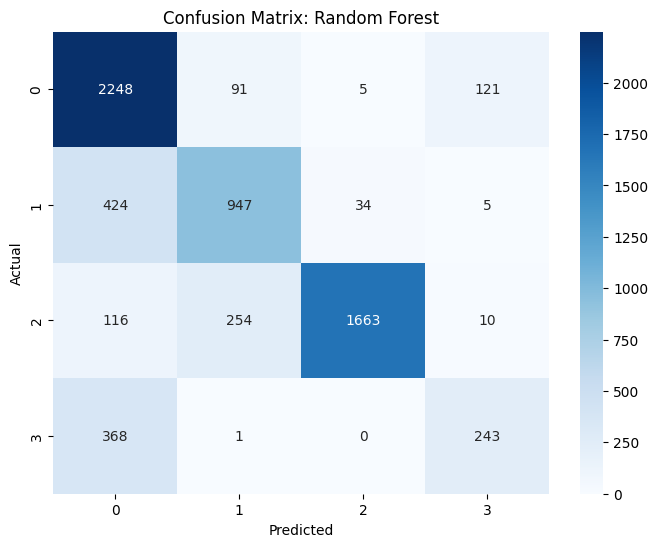

In [7]:
y_pred_rf = final_model.predict(X_test)


y_test = y_test.to_pandas().values if hasattr(y_test, 'to_pandas') else y_test
y_pred_rf = y_pred_rf.to_pandas().values if hasattr(y_pred_rf, 'to_pandas') else y_pred_rf
print("Random Forest Evaluation:")
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 4. XGBoost

Using XGBoost with `tree_method='gpu_hist'` for GPU acceleration.

In [8]:
# 1. Convert GPU data to numpy/pandas for splitting and XGBoost
X_train_full = X_train.to_pandas().values if hasattr(X_train, 'to_pandas') else X_train
y_train_full = y_train.to_pandas().values if hasattr(y_train, 'to_pandas') else y_train
X_test_xgb = X_test.to_pandas().values if hasattr(X_test, 'to_pandas') else X_test

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# 2. Định nghĩa hàm mục tiêu cho Optuna
def objective(trial):
    # Không gian siêu tham số cho XGBoost
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), 
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }

    model = XGBClassifier(
        **params,
        tree_method='hist',
        device='cuda',
        scale_pos_weight=4, 
        random_state=42,
        verbosity=0,
        early_stopping_rounds=20 
    )

    # Fit model với tập validation
    model.fit(
        X_train_sub, y_train_sub,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # Dự đoán và tính điểm
    preds = model.predict(X_val)
    return accuracy_score(y_val, preds)

# 4. Chạy quá trình tối ưu Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50) 

print(f"Best Validation Accuracy: {study.best_value:.4f}")
print(f"Best Params: {json.dumps(study.best_params, indent=4)}")

# 5. Huấn luyện lại mô hình cuối cùng với bộ tham số tốt nhất
best_params = study.best_params

final_xgb_model = XGBClassifier(
    **best_params,
    tree_method='hist',
    device='cuda',
    scale_pos_weight=4,
    random_state=42,
    verbosity=0
)

# Chú ý: Khi train trên toàn bộ dữ liệu (không có eval_set), ta không dùng early_stopping_rounds nữa
final_xgb_model.fit(X_train_full, y_train_full, verbose=False)

# 6. Đánh giá trên tập Test
y_pred_xgb = final_xgb_model.predict(X_test_xgb)

elapsed = time.time() - start_time
accuracy = accuracy_score(y_test, y_pred_xgb)

[I 2026-04-16 11:07:46,125] A new study created in memory with name: no-name-35ea5765-fce9-4c11-adf5-8387293512b8
[I 2026-04-16 11:07:53,462] Trial 0 finished with value: 0.813926721657395 and parameters: {'n_estimators': 955, 'max_depth': 11, 'learning_rate': 0.05237589208160457, 'subsample': 0.9245064319255237, 'colsample_bytree': 0.638701458642948}. Best is trial 0 with value: 0.813926721657395.
[I 2026-04-16 11:07:54,456] Trial 1 finished with value: 0.8072127373873009 and parameters: {'n_estimators': 806, 'max_depth': 6, 'learning_rate': 0.15489173646435117, 'subsample': 0.7724717904120789, 'colsample_bytree': 0.6190420700725779}. Best is trial 0 with value: 0.813926721657395.
[I 2026-04-16 11:07:55,149] Trial 2 finished with value: 0.8072127373873009 and parameters: {'n_estimators': 602, 'max_depth': 5, 'learning_rate': 0.26337188444863574, 'subsample': 0.6365982877343129, 'colsample_bytree': 0.6029361114216468}. Best is trial 0 with value: 0.813926721657395.
[I 2026-04-16 11:07:

Best Validation Accuracy: 0.8199
Best Params: {
    "n_estimators": 740,
    "max_depth": 11,
    "learning_rate": 0.04651419756395734,
    "subsample": 0.9163420915920394,
    "colsample_bytree": 0.9990406374701188
}


XGBoost Evaluation:
              precision    recall  f1-score   support

           0       0.75      0.91      0.82      2465
           1       0.74      0.71      0.73      1410
           2       0.97      0.83      0.89      2043
           3       0.65      0.46      0.53       612

    accuracy                           0.80      6530
   macro avg       0.78      0.73      0.74      6530
weighted avg       0.81      0.80      0.80      6530



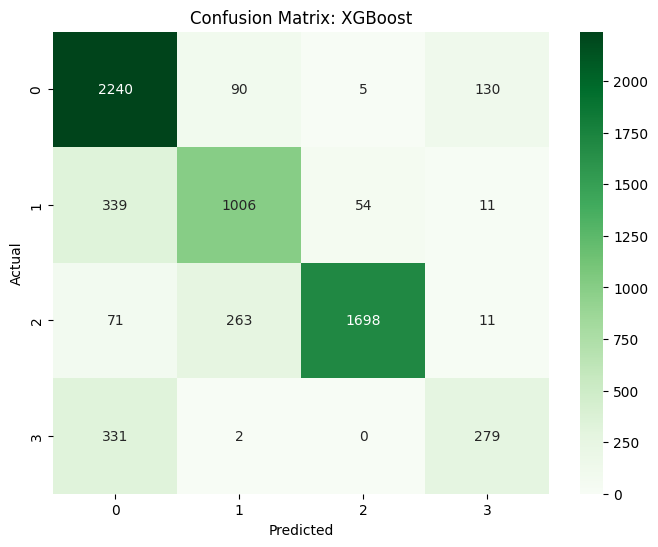

In [9]:
print("XGBoost Evaluation:")
print(classification_report(y_test, y_pred_xgb))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix: XGBoost")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 5. LightGBM

Using LightBGM with GPU acceleration.

In [6]:
X_train_full = X_train.to_pandas().values if hasattr(X_train, 'to_pandas') else X_train
y_train_full = y_train.to_pandas().values if hasattr(y_train, 'to_pandas') else y_train
X_test_lgb = X_test.to_pandas().values if hasattr(X_test, 'to_pandas') else X_test

# 2. Chia dữ liệu thành Train (80%) và Validation (20%)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# 3. Định nghĩa hàm mục tiêu cho Optuna
def objective(trial):
    # Không gian tham số cho LightGBM
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150), # Rất quan trọng trong LightGBM
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100), # Tránh overfit
    }

    # Cấu hình device
    device_type = 'gpu'

    model = LGBMClassifier(
        **params,
        device_type=device_type,
        random_state=42,
        verbose=-1, # Tắt các log cảnh báo của LightGBM
        # class_weight='balanced' # Bỏ comment dòng này nếu data bị mất cân bằng (imbalanced)
    )

    # Fit model với Early Stopping
    model.fit(
        X_train_sub, y_train_sub,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
    )

    # Dự đoán và tính điểm
    preds = model.predict(X_val)
    return accuracy_score(y_val, preds)

# 4. Chạy quá trình tối ưu Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(f"Best Validation Accuracy: {study.best_value:.4f}")
print(f"Best Params: {json.dumps(study.best_params, indent=4)}")

# 5. Huấn luyện lại mô hình cuối cùng trên toàn bộ dữ liệu Train
best_params = study.best_params

final_lgb_model = LGBMClassifier(
    **best_params,
    device_type='gpu',
    random_state=42,
    verbose=-1
)

final_lgb_model.fit(X_train_full, y_train_full)

# 6. Đánh giá trên tập Test
y_pred_lgb = final_lgb_model.predict(X_test_lgb)

elapsed = time.time() - start_time
accuracy = accuracy_score(y_test, y_pred_lgb)

print(f"\n✓ Pipeline Complete!")
print(f"  Total Time: {elapsed:.2f}s")
print(f"  Final Test Accuracy: {accuracy:.4f}")

[I 2026-04-16 13:30:20,949] A new study created in memory with name: no-name-1125e06c-0b6a-46e2-abaa-8f1d0727317e
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
[I 2026-04-16 13:30:29,338] Trial 0 finished with value: 0.8079800498753117 and parameters: {'n_estimators': 631, 'learning_rate': 0.1293154638144598, 'num_leaves': 134, 'max_depth': 8, 'subsam

Best Validation Accuracy: 0.8187
Best Params: {
    "n_estimators": 942,
    "learning_rate": 0.013216166632867694,
    "num_leaves": 127,
    "max_depth": 10,
    "subsample": 0.962597432280253,
    "colsample_bytree": 0.810303293177885,
    "min_child_samples": 92
}

✓ Pipeline Complete!
  Total Time: 851.10s
  Final Test Accuracy: 0.8005


LightGBM Evaluation:
              precision    recall  f1-score   support

           0       0.75      0.90      0.82      2465
           1       0.74      0.72      0.73      1410
           2       0.97      0.83      0.90      2043
           3       0.64      0.47      0.54       612

    accuracy                           0.80      6530
   macro avg       0.78      0.73      0.75      6530
weighted avg       0.81      0.80      0.80      6530



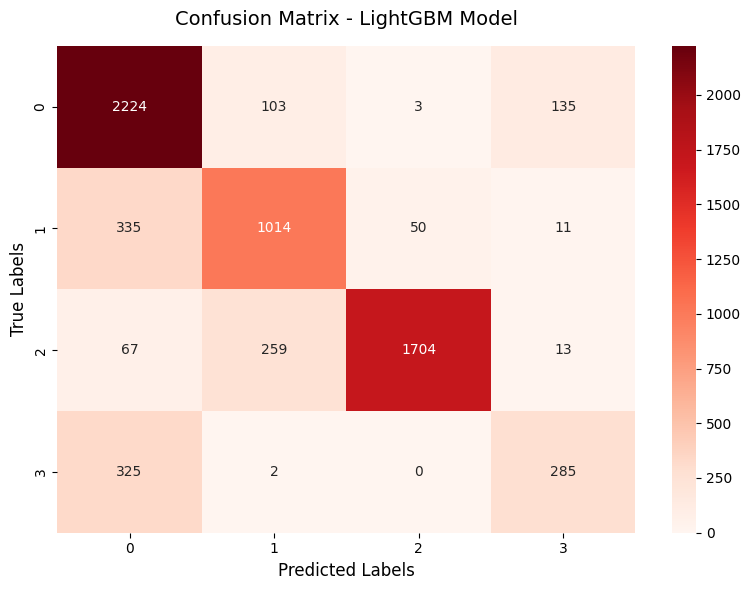

In [7]:
print("LightGBM Evaluation:")
print(classification_report(y_test, y_pred_lgb))

cm = confusion_matrix(y_test, y_pred_lgb)

# Khởi tạo khung biểu đồ
plt.figure(figsize=(8, 6))

# Vẽ biểu đồ nhiệt (heatmap)
# annot=True: Hiển thị số lượng bên trong từng ô
# fmt='d': Định dạng số nguyên
# cmap='Blues': Sử dụng dải màu xanh dương
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=sorted(set(y_test)), 
            yticklabels=sorted(set(y_test)))

# Thêm tiêu đề và nhãn dán
plt.title('Confusion Matrix - LightGBM Model', fontsize=14, pad=15)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)

# Điều chỉnh layout và hiển thị
plt.tight_layout()
plt.show()

## 6. Model Comparison

Compare performance of Random Forest vs XGBoost vs LightBGM

Random Forest:
   Accuracy: 0.7812 | F1 Score: 0.7771
XGBoost:
   Accuracy: 0.7998 | F1 Score: 0.7971
LightGBM:
   Accuracy: 0.8051 | F1 Score: 0.8030
WINNER: LightGBM (Accuracy: 0.8051)
Beat 2nd place (XGBoost) by: 0.0052


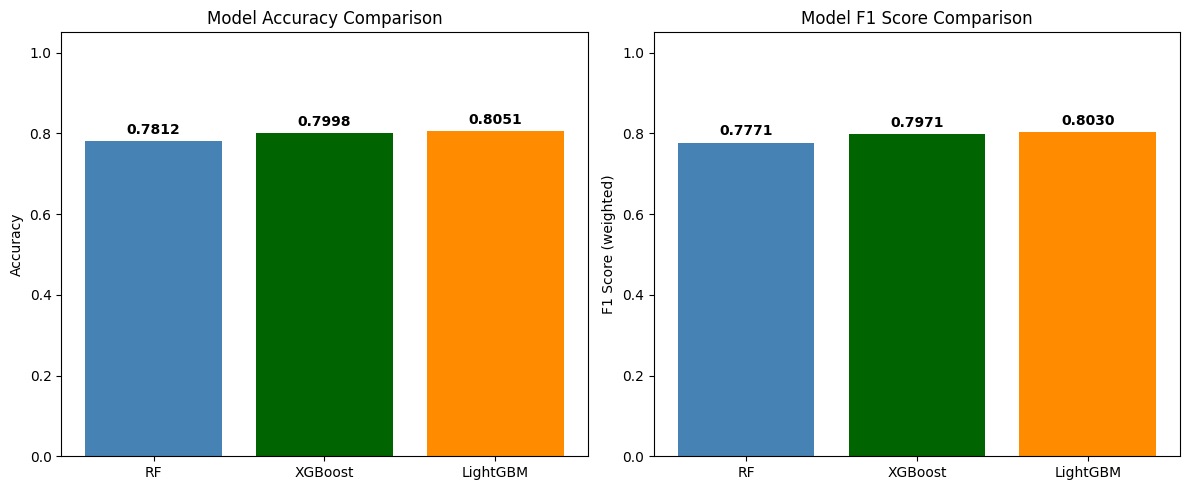

In [11]:
# 1. Calculate Metrics
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

lgb_acc = accuracy_score(y_test, y_pred_lgb)
lgb_f1 = f1_score(y_test, y_pred_lgb, average='weighted')

# 2. Print Detailed Stats
print("Random Forest:")
print(f"   Accuracy: {rf_acc:.4f} | F1 Score: {rf_f1:.4f}")

print("XGBoost:")
print(f"   Accuracy: {xgb_acc:.4f} | F1 Score: {xgb_f1:.4f}")

print("LightGBM:")
print(f"   Accuracy: {lgb_acc:.4f} | F1 Score: {lgb_f1:.4f}")

# 3. Determine Winner automatically
scores = {
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc,
    'LightGBM': lgb_acc
}
# Xếp hạng từ cao xuống thấp
sorted_scores = sorted(scores.items(), key=lambda item: item[1], reverse=True)
winner_name, winner_score = sorted_scores[0]
runner_up_name, runner_up_score = sorted_scores[1]

print(f"WINNER: {winner_name} (Accuracy: {winner_score:.4f})")
print(f"Beat 2nd place ({runner_up_name}) by: {abs(winner_score - runner_up_score):.4f}")

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5)) # Tăng chiều cao lên 5 để nhìn thoáng hơn

models = ['RF', 'XGBoost', 'LightGBM']
accuracies = [rf_acc, xgb_acc, lgb_acc]
f1_scores = [rf_f1, xgb_f1, lgb_f1]
colors = ['steelblue', 'darkgreen', 'darkorange'] # Thêm màu cam cho LightGBM

# Accuracy Plot
bars1 = ax1.bar(models, accuracies, color=colors)
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylim([0, 1.05]) # Đặt limit là 1.05 để chừa chỗ cho text bên trên
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

# F1 Score Plot
bars2 = ax2.bar(models, f1_scores, color=colors)
ax2.set_ylabel('F1 Score (weighted)')
ax2.set_title('Model F1 Score Comparison')
ax2.set_ylim([0, 1.05])
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()